In [2]:
# Studying a piece of land and analyzing the geography for use with irrigation

# Add the Python ArcGIS package to the default Anaconda packages that were installed during Navigator install
# !pip install arcgis

In [3]:
import arcgis
from arcgis.gis import GIS
# from arcgis.raster.functions import *
# from ipywidgets import *

C:\Users\Johanna\anaconda3\envs\py36\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


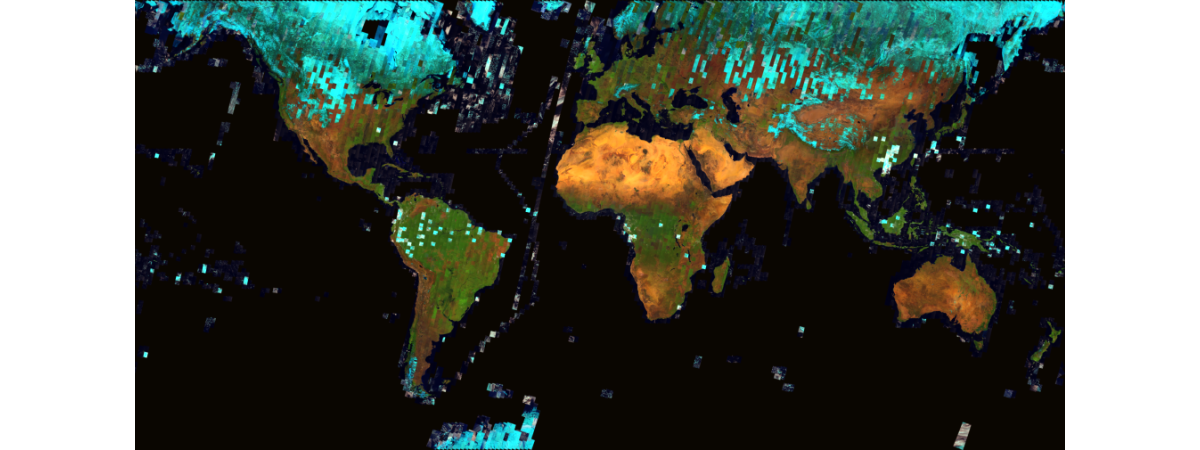

In [4]:
gis = GIS()

arcgis.raster.analytics.is_supported(gis)

search_item = gis.content.search('title:Multispectral Landsat', 'Imagery Layer', outside_org=True)[0]
landsat = search_item.layers[0]

landsat

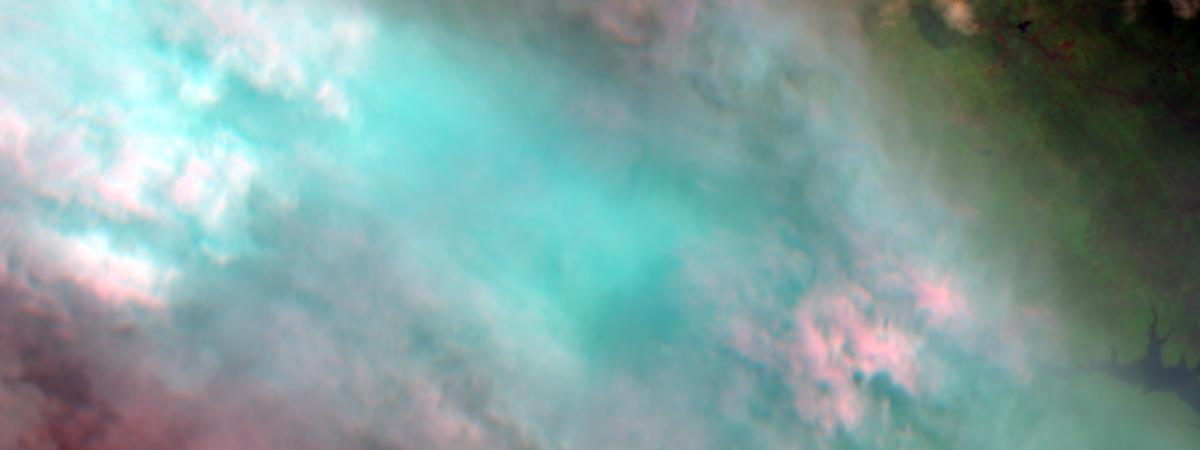

In [5]:
# Access ArcGIS online tools to get a satellite image of the Bangalore region

from arcgis.geocoding import geocode

extent = geocode("Kandi", "India", out_sr=landsat.properties.spatialReference)[1]
landsat.extent = extent['extent']
landsat

In [6]:
# Use the GMRT online mapping tool to get terrain for an area east of Bangalore
# https://www.gmrt.org/GMRTMapTool/

# Bangalore is centered at: [12.971599, 77.594566]
# So use bounds of [12.99, 77.59] and [13.01, 77.57]

# Save the terrain grid as ArcASCII File Format, and High Grid Resolution
# It downloads an .asc file with 39 columns and 35 rows

# Read in the terrain to a two-dimensional array:

import numpy as np

Terrain  = np.loadtxt("kandiactual.asc", skiprows=6)
Terrain.shape

(863, 328)

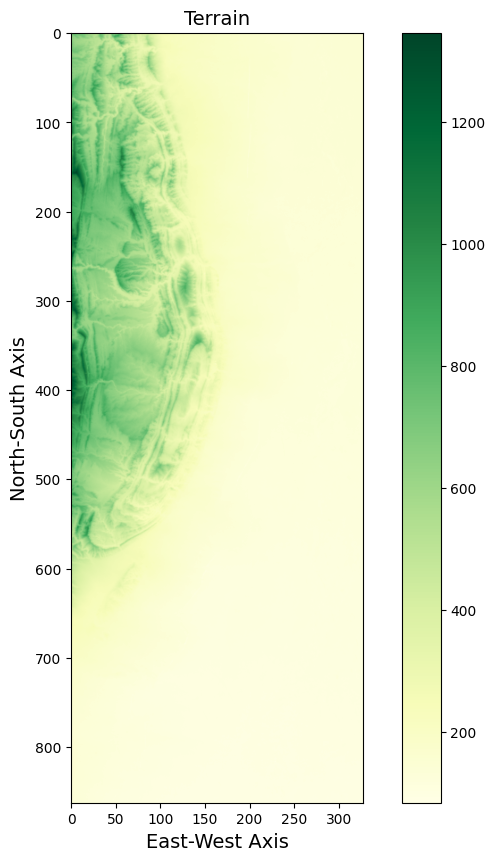

In [7]:
#Plot the terrain to see it visually

import matplotlib.pyplot as plt
from PIL import Image  #images processing package

def plot_terrain():
    #plot vegetation cover
    plt.figure(figsize=(10, 10))
    plt.imshow(Terrain)

    plt.xlabel('East-West Axis', fontsize=14)
    plt.ylabel('North-South Axis', fontsize=14)
    plt.title('Terrain', fontsize=14);
    plt.set_cmap("YlGn")
    plt.colorbar()
    
    plt.show()
        
plot_terrain()

In [8]:
# Set a uniform soil depth at all locations

nx = len(Terrain[0])
ny = len(Terrain)

# create soil data array
Soil = np.zeros([ny, nx], dtype = float)

def fill_soil_grid():
    #fill the Soil grid
    for i in range(0, nx): #march east to west
        for j in range(0, ny): #march south to north
            Soil[j][i] = 30

fill_soil_grid()

# Set a uniform water table depth at all locations

nx = len(Terrain[0])
ny = len(Terrain)

# create soil data array
Winit = np.zeros([ny, nx], dtype = float)
def fill_vegetation_grid():
    for i in range(ny):
        for j in range(nx):
            if 650 <= i < 750:
                Vegetation[i,j] = 0.2  # Initial value for Black Gram
            elif i >= 750:
                Vegetation[i,j] = 0.3  # Higher initial value for Maize
            else:
                Vegetation[i,j] = 0  # No vegetation in other areas
def fill_water_table_grid():
    #fill the Water grid
    for i in range(0, nx): #march east to west
        for j in range(0, ny): #march south to north
            Winit[j][i] = 2

fill_water_table_grid()
# # create soil data array
Vegetation = np.zeros([ny, nx], dtype = float)

fill_vegetation_grid()

#add a reservoir to fill canals at pixel 326, 668
Winit[667,325] = Soil[667,325] + 2
Vegetation[667,325] = 0

nx = len(Terrain[0])
ny = len(Terrain)





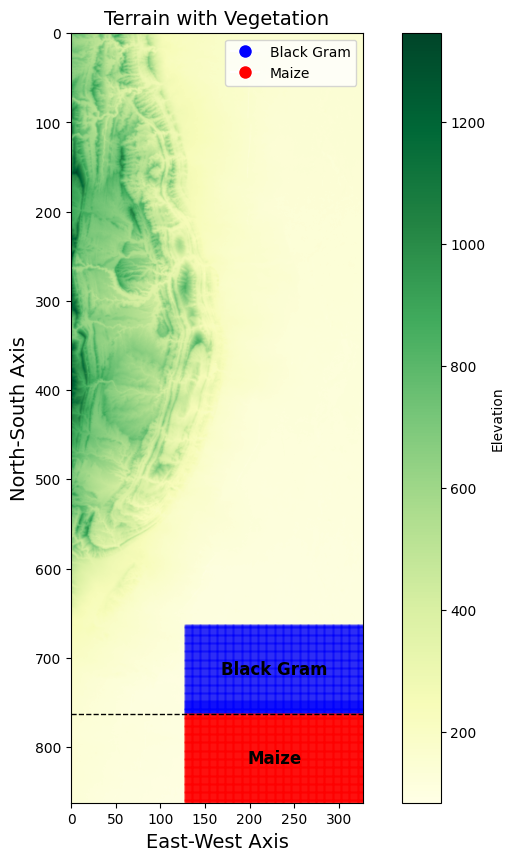

In [9]:
plt.figure(figsize=(10, 10))
plt.imshow(Terrain)
plt.xlabel('East-West Axis', fontsize=14)
plt.ylabel('North-South Axis', fontsize=14)
plt.title('Terrain with Vegetation', fontsize=14)
plt.set_cmap("YlGn")
plt.colorbar(label='Elevation')

# Plot vegetation in the southeast quadrant
for i in range(ny-200, ny):
    for j in range(nx-200, nx):
        if i < ny-100:  # Black Gram area (upper half of the southeast quadrant)
            if Vegetation[i, j] > 0:
                plt.plot(j, i, 'bo', ms=1, alpha=Vegetation[i, j])
        else:  # Maize area (lower half of the southeast quadrant)
            if Vegetation[i, j] > 0:
                plt.plot(j, i, 'ro', ms=1, alpha=Vegetation[i, j])

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Black Gram',
                          markerfacecolor='b', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Maize',
                          markerfacecolor='r', markersize=10)]
plt.legend(handles=legend_elements, loc='upper right')

# Add text labels for crop areas
plt.text(nx - 100, ny - 150, 'Black Gram', color='black', fontsize=12, fontweight='bold', ha='center', va='center')
plt.text(nx - 100, ny - 50, 'Maize', color='black', fontsize=12, fontweight='bold', ha='center', va='center')

# Highlight crop areas
plt.axhline(y=ny-100, color='black', linestyle='--', linewidth=1)

plt.show()

In [10]:
#Calculate the water surface flow

import numpy as np

def calculate_flow(dem):
    rows, cols = dem.shape
    flow_direction = np.zeros((rows, cols), dtype=int)
    flow_slope = np.zeros((rows, cols), dtype=float)
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            max_slope = 0
            direction = 0
            current_elevation = dem[i, j]
            for di, dj, d in [(-1, 0, 1), (1, 0, 1), (0, -1, 1), (0, 1, 1), (-1, -1, np.sqrt(2)), (-1, 1, np.sqrt(2)), (1, -1, np.sqrt(2)), (1, 1, np.sqrt(2))]:
                neighbor_elevation = dem[i + di, j + dj]
                slope = (current_elevation - neighbor_elevation) / d
                if slope > max_slope:
                    max_slope = slope
                    direction = (di + 1) * 3 + (dj + 1)
            flow_direction[i, j] = direction
            flow_slope[i, j] = max_slope
    return [flow_direction, flow_slope]

# Example DEM
dem = Terrain

result = calculate_flow(dem)
flow_direction = result[0]
slope = result[1]

print(slope[3][3])

23.770000000000095


In [11]:
min_temp = 0  # Minimum temperature in Celsius
max_temp = 35  # Maximum temperature in Celsius

# Example constant temperature in Celsius
actual_temperature = np.ones((ny, nx)) * 32  # Example constant temperature of 32°C

# Normalize the temperature between 0 and 1
normalized_temperature = (actual_temperature - min_temp) / (max_temp - min_temp)

def calculate_evapotranspiration(water_level, vegetation_density, temperature):
    base_evap = 0.001 * (1 + temperature / 30)  # Temperature-dependent base evaporation
    veg_factor = 1 - 0.5 * vegetation_density  # Vegetation reduces evaporation
    water_factor = min(1, water_level / 2)  # Water availability affects evaporation
    return base_evap * veg_factor * water_factor

In [12]:
import numpy as np

In [13]:
drought_start_day = 2  # Start drought on day 3
drought_duration_days = 3  # Drought lasts for 3 days
drought_severity = 0.7  # Severity when drought is in effect

# Function to determine if it's currently a drought period
def is_drought_period(current_day):
    return drought_start_day <= current_day < (drought_start_day + drought_duration_days)

def get_drought_severity(current_day):
    if drought_start_day <= current_day < (drought_start_day + drought_duration_days):
        progress = (current_day - drought_start_day) / drought_duration_days
        return drought_severity * (1 - np.exp(-3 * progress))  # Exponential ramp-up
    return 0

In [14]:
def create_canal_system(terrain):
    canals = np.zeros((ny, nx), dtype=bool)
    for i in range(ny-200, ny):
        for j in range(nx-200, nx):  # Place a canal every 10 cells horizontally
            if(i%10==0 or j==326):   # And a vertical canal to connect to reservoir
                canals[i, j] = True
    return canals

canals = create_canal_system(Terrain)

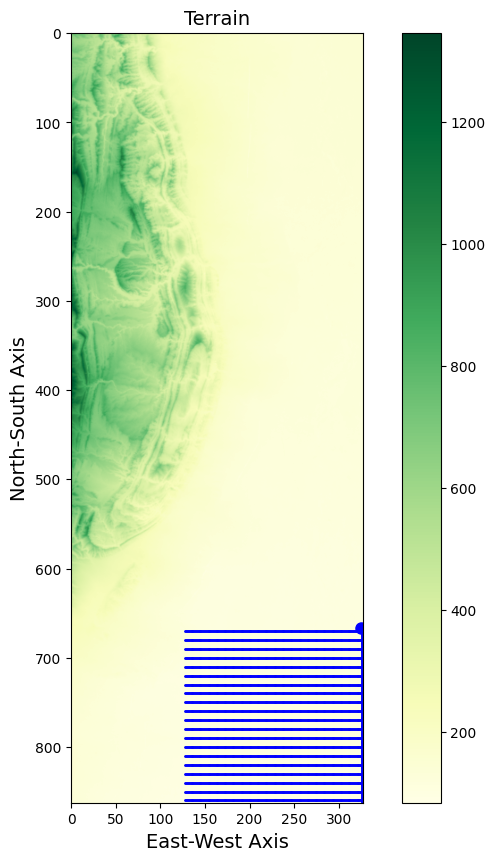

In [15]:
canal_x = []
canal_y = []

#plot the canals upon the terrain
plt.figure(figsize=(10, 10))
plt.imshow(Terrain)

plt.xlabel('East-West Axis', fontsize=14)
plt.ylabel('North-South Axis', fontsize=14)
plt.title('Terrain', fontsize=14);
plt.set_cmap("YlGn")
plt.colorbar()

for i in range(ny-200, ny):
    for j in range(nx-200, nx):  # Plot the canals
        if canals[i, j] == True:
            canal_x.append(j)
            canal_y.append(i)
            plt.plot(j, i,'bo', ms=1)

# Plot a reservoir
plt.plot(325, 667,'bo', ms=8)

plt.show()

In [16]:
import random

Precip = np.zeros([ny, nx], dtype = float)

def fill_precipitation_grid():
    #fill the Precipitation grid
    for i in range(0, nx): #march east to west
        for j in range(0, ny): #march south to north
            Precip[j][i] = (5 + random.random()*2)/(31*24) # convert annual amount of rain to hourly

fill_precipitation_grid()

# def calculate_growth_rate(water_table, precipitation, water_coefficient, precip_coefficient):
#     growth_rate = (water_table.mean() * water_coefficient) + (precipitation.mean() * precip_coefficient)
#     return growth_rate


In [17]:
def create_porosity_map(terrain):
    porosity = np.zeros_like(terrain, dtype=float)
    for i in range(ny):
        for j in range(nx):
            if terrain[i,j] < 500:  # Assuming lower elevations have more clay
                porosity[i,j] = 0.4  # Clay soils
            elif 500 <= terrain[i,j] < 1000:  # Mid elevations
                porosity[i,j] = 0.5  # Loamy soils
            else:  # Higher elevations
                porosity[i,j] = 0.6  # Sandy soils
    return porosity

porosity_map = create_porosity_map(Terrain)

In [18]:
def calculate_root_water_intake(water_table, vegetation_density, crop_type):
    max_intake = 0.02 if crop_type == 'maize' else 0.015  # Max water intake per hour
    water_availability = min(1, water_table / 10)  # Assume max root depth of 10 units
    return max_intake * vegetation_density * water_availability

In [19]:
cumulative_stress = np.zeros((ny, nx))
recovery_factor = 0.0

In [20]:
# def calculate_precipitation(drought_severity, day):
#     if np.random.random() < 0.1:  # 10% chance of rainfall event
#         base_precip = np.random.uniform(0.1, 0.5)  # Significant rainfall when it occurs
#         drought_factor = 1 - drought_severity
#         return base_precip * drought_factor
#     return 0  # No precipitation most of the time
# def calculate_evapotranspiration(water_level, vegetation_density, temperature):
#     base_evap = 0.002 * (1 + temperature / 30)  # Increased base evaporation
#     veg_factor = 1 - 0.3 * vegetation_density  # Adjusted vegetation effect
#     water_factor = min(1, water_level / 2)  # Water availability affects evaporation
#     random_factor = np.random.uniform(0.8, 1.2)  # Added random factor
#     return base_evap * veg_factor * water_factor * random_factor

In [21]:
def calculate_precipitation(drought_severity, day):
    base_precip = 0.05  # Base precipitation rate
    seasonal_factor = 1 + 0.2 * np.sin(2 * np.pi * day / 365)  # Yearly seasonality
    daily_factor = 1 + 0.1 * np.sin(2 * np.pi * day)  # Daily variation
    drought_factor = 1 - drought_severity
    random_factor = np.random.uniform(0.8, 1.2)  # Random variation
    return max(0, base_precip * seasonal_factor * daily_factor * drought_factor * random_factor)

In [22]:
def simulate_rainfall(day, drought_severity):
    if random.random() < 0.3 and drought_severity == 0:  # 30% chance of rain when not in drought
        return random.uniform(0.1, 0.5)  # Random amount of rainfall
    return 0

In [23]:
reservoir_level = 32  # Initial reservoir level

def manage_reservoir(current_drought_severity, precipitation):
    global reservoir_level
    base_outflow = 0.2
    outflow = base_outflow * (1 - current_drought_severity)
    inflow = precipitation * 2 + simulate_rainfall(current_day, current_drought_severity)
    reservoir_level += inflow - outflow
    reservoir_level = max(28, min(reservoir_level, 35))
    return reservoir_level

In [24]:
def water_diffusion(k, i, j):
    # Define diffusion coefficients (reduced for more localized effects)
    Kh = 1e-6  # Horizontal diffusivity (reduced)
    Kv = 1e-6  # Vertical diffusivity (reduced)
    
    # Get current water level
    current_water = W[i,j,k-1]
    
    # Initialize diffusion result
    result = current_water
    
    # Horizontal diffusion (reduced effect)
    if j > 0 and j < nx-1:
        left_diff = (W[i,j-1,k-1] - current_water) * Kh * porosity_map[i,j-1]
        right_diff = (W[i,j+1,k-1] - current_water) * Kh * porosity_map[i,j+1]
        result += (left_diff + right_diff) * (dt/dx**2)
    
    # Vertical diffusion (reduced effect)
    if i > 0 and i < ny-1:
        top_diff = (W[i-1,j,k-1] - current_water) * Kv * porosity_map[i-1,j]
        bottom_diff = (W[i+1,j,k-1] - current_water) * Kv * porosity_map[i+1,j]
        result += (top_diff + bottom_diff) * (dt/dy**2)
    
    # Add some random variability to simulate small-scale heterogeneity
    result += np.random.normal(0, 0.01)  # Increased random fluctuation
    
    # Ensure non-negative water levels
    return max(0, result)

In [25]:
# def water_diffusion(k, i, j):
#     # Define diffusion coefficients
#     Kh = 2.895e-5  # Horizontal diffusivity
#     Kv = 2.895e-5  # Vertical diffusivity
    
#     # Get current water level
#     current_water = W[i,j,k-1]
    
#     # Initialize diffusion result
#     result = current_water
    
#     # Horizontal diffusion
#     if j > 0 and j < nx-1:
#         left_diff = (W[i,j-1,k-1] - current_water) * Kh * porosity_map[i,j-1]
#         right_diff = (W[i,j+1,k-1] - current_water) * Kh * porosity_map[i,j+1]
#         result += (left_diff + right_diff) * (dt/dx**2)
    
#     # Vertical diffusion
#     if i > 0 and i < ny-1:
#         top_diff = (W[i-1,j,k-1] - current_water) * Kv * porosity_map[i-1,j]
#         bottom_diff = (W[i+1,j,k-1] - current_water) * Kv * porosity_map[i+1,j]
#         result += (top_diff + bottom_diff) * (dt/dy**2)
    
#     # Capillary action (upward movement of water)
#     if i < ny-1:
#         capillary_strength = 0.005  # Adjust this value based on soil properties
#         capillary_flow = capillary_strength * (W[i+1,j,k-1] - current_water) * porosity_map[i,j]
#         result += capillary_flow * (dt/dy)
    
#     # Boundary conditions
#     if i == 0:  # Top boundary
#         result = max(result, W[1,j,k-1])  # Prevent water from leaving the top
#     elif i == ny-1:  # Bottom boundary
#         result = min(result, W[ny-2,j,k-1])  # Prevent water from accumulating at the bottom
    
#     if j == 0:  # Left boundary
#         result = max(result, W[i,1,k-1])  # Prevent water from leaving the left side
#     elif j == nx-1:  # Right boundary
#         result = min(result, W[i,nx-2,k-1])  # Prevent water from accumulating at the right side
    
#     # Add some random variability to simulate small-scale heterogeneity
#     result += np.random.normal(0, 0.0001 * porosity_map[i,j])
    
#     # Ensure non-negative water levels
#     return max(0, result)

Day: 1.0, Drought Severity: 0.00
Black Gram: 0.2000, Maize: 0.3001
Water Table - Black Gram: 2.7099, Maize: 2.6683
Day: 2.0, Drought Severity: 0.00
Black Gram: 0.2002, Maize: 0.3004
Water Table - Black Gram: 3.4184, Maize: 3.3740
Day: 3.0, Drought Severity: 0.44
Black Gram: 0.2003, Maize: 0.3006
Water Table - Black Gram: 3.2085, Maize: 3.2152
Day: 4.0, Drought Severity: 0.61
Black Gram: 0.2004, Maize: 0.3008
Water Table - Black Gram: 3.1389, Maize: 3.1536
Day: 5.0, Drought Severity: 0.00
Black Gram: 0.2004, Maize: 0.3009
Water Table - Black Gram: 3.2608, Maize: 3.2155
Day: 6.0, Drought Severity: 0.00
Black Gram: 0.2006, Maize: 0.3012
Water Table - Black Gram: 3.7563, Maize: 3.6726
Day: 7.0, Drought Severity: 0.00
Black Gram: 0.2010, Maize: 0.3019
Water Table - Black Gram: 4.6023, Maize: 4.3011
Sim Run Time 287899.3479003906 milliseconds


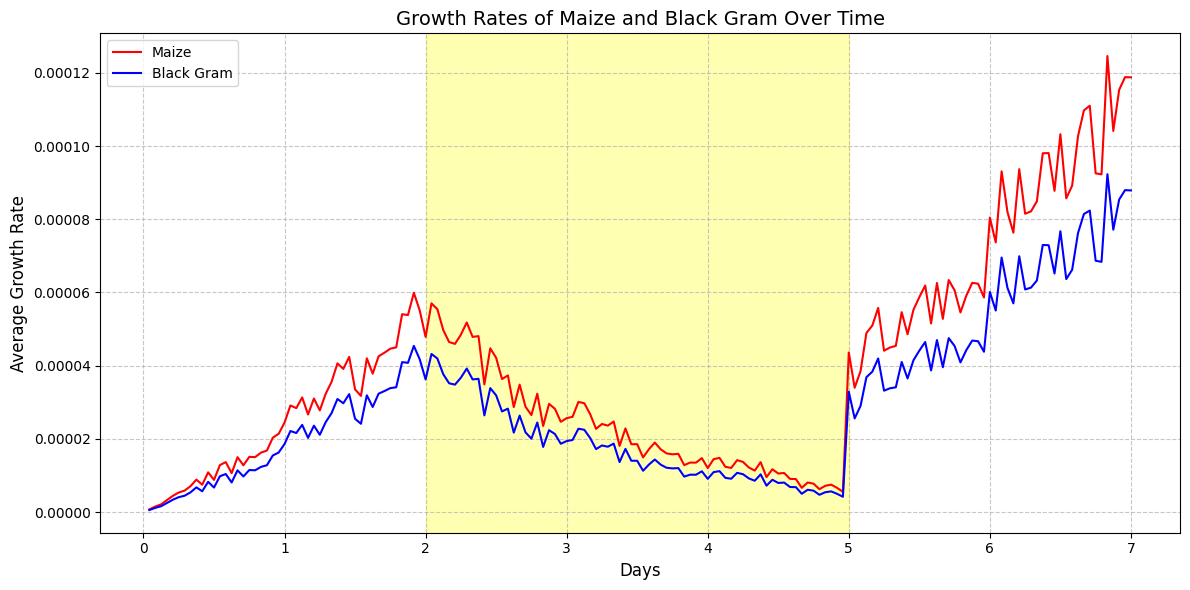

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

# Define dimensions and parameters
ny, nx = 863, 328  # Adjust these to match your Terrain dimensions
ntimes = 7*24+1  # Number of time steps (seven days)
dt = 3600  # Time per time step (one hour)

# Define the southeast region
se_start_row = ny - 200
se_start_col = nx - 200
canal_flow = 2.855e10 # cm^3/second  #flow of river at start

#Define the Parameters (lengths all in cm)
L=390000;  # length of estuary in cm (3.9 kilometers) East-West Distance
h=350000;  # width of estuary in cm (3.5 kilometers)  North-South Distance
dx=10000;  # E-W grid spacing in cm (100 meters) East-West Spacing
dy=10000;  # N-S grid spacing in cm (100 meters) North-South Spacing

#Factors controlling water diffusion
Kh=2.895e-5; # TO RESEARCH: horizontal diffusivity (2.895 x 10^-5 cm^2/s)
Kv=2.895e-5; # TO RESEARCH: vertical diffusivity   (2.895 x 10^-5 cm^2/s)

ntimes=7*24+1; # number of time steps (seven days)
dt=3600;

# Set up water diffusion parameters
Kh = 2.895e-5  # Horizontal diffusivity
Kv = 2.895e-5  # Vertical diffusivity

# Set up drought parameters
drought_start_day = 2
drought_duration_days = 3
drought_severity = 0.7

def is_drought_period(current_day):
    return drought_start_day <= current_day < (drought_start_day + drought_duration_days)


# def water_diffusion(k, i, j):
#     if i == 0 or i == ny-1 or j == 0 or j == nx-1:
#         return W[i,j,k-1]  # No diffusion at edges
    
#     diffusion_rate = Kh * porosity_map[i,j]  # Adjust diffusion rate based on porosity
    
#     result = W[i,j,k-1] + diffusion_rate*(dt/dx**2)*(W[i,j+1,k-1]-2*W[i,j,k-1]+W[i,j-1,k-1])
#     result += diffusion_rate*(dt/dy**2)*(W[i+1,j,k-1]-2*W[i,j,k-1]+W[i-1,j,k-1])
    
#     # Add some random variability
#     result += np.random.normal(0, 0.001 * porosity_map[i,j])  # Variability scaled by porosity
    
#     return result

def calculate_growth_rate(water_table, precipitation, crop_type, drought_severity, day, cumulative_stress, temperature):
    # Reduced base growth rates
    base_rate = 0.015 if crop_type == 'maize' else 0.0125  # Halved the original rates
    
    # Water availability factor (less sensitive sigmoid function)
    optimal_water = 1.5  # Optimal water level
    water_factor = 1.5 / (1 + np.exp(-1 * (water_table - optimal_water))) - 0.25
    
    # Precipitation factor (less sensitive logarithmic response)
    precip_factor = np.log1p(precipitation * 5) / np.log1p(10)  # Reduced sensitivity
    
    # Temperature factor (wider bell-shaped curve)
    optimal_temp = 25 if crop_type == 'maize' else 22
    temp_factor = np.exp(-0.25 * ((temperature - optimal_temp) / 5)**2)
    
    # Drought effect (less severe exponential decay)
    drought_factor = np.exp(-1 * drought_severity)
    
    # Cumulative stress effect (less sensitive sigmoid function)
    stress_factor = 1 - (1 / (1 + np.exp(-5 * (cumulative_stress - 0.5))))
    
    # Time-dependent factor (reduced seasonal effects)
    time_factor = 1 + 0.1 * np.sin(2 * np.pi * day / 30)  # Monthly cycle, reduced amplitude
    
    # Nutrient availability (slower decrease over time)
    nutrient_factor = max(0.7, 1 - day / 240)  # Slower decrease, higher minimum
    
    # Plant maturity factor (slower logistic growth curve)
    maturity = min(1, day / 150)  # Increased time to full maturity
    maturity_factor = 3 * maturity * (1 - maturity)
    
    # Combine all factors
    growth_rate = (base_rate 
                   * water_factor 
                   * precip_factor 
                   * temp_factor 
                   * drought_factor 
                   * stress_factor 
                   * time_factor 
                   * nutrient_factor 
                   * maturity_factor)
    
    # Add some randomness to simulate natural variability (reduced variability)
    growth_rate *= np.random.normal(1, 0.03)
    
    # Cap the maximum growth rate
    max_growth_rate = 0.05  # Adjust this value as needed
    growth_rate = min(growth_rate, max_growth_rate)
    
    # Ensure non-negative growth rate
    return max(0, growth_rate)

def calculate_temperature(day):
    base_temp = 25  # Average temperature
    amplitude = 5   # Temperature variation
    return base_temp + amplitude * np.sin(2 * np.pi * day / 365)
# Initialize water array
W = np.zeros((ny, nx, ntimes))
W[:,:,0] = Winit

# Set whether W represents height or depth
W_is_height = True
maize_growth_rates = []
black_gram_growth_rates = []

# Main simulation loop
sim_start_time = time.time() * 1000.0
maize_growth_rates = []
black_gram_growth_rates = []

for t in range(1, ntimes):
    current_day = t / 24
    current_drought_severity = get_drought_severity(current_day)
    precipitation = calculate_precipitation(current_drought_severity, current_day)
    rainfall = simulate_rainfall(current_day, current_drought_severity)
    temperature = calculate_temperature(current_day)
    reservoir_level = manage_reservoir(current_drought_severity, precipitation + rainfall)
    
    maize_gr_sum = 0
    black_gram_gr_sum = 0
    maize_count = 0
    black_gram_count = 0
    
    for i in range(se_start_row, ny):
        for j in range(se_start_col, nx):
            # Water diffusion
            W[i,j,t] = water_diffusion(t, i, j)
            
            # Add rainfall
            W[i,j,t] += rainfall * porosity_map[i,j]
            
            # Canal water addition
            if canals[i, j]:
                W[i,j,t] += 0.01 * (reservoir_level - 28) / 7 * porosity_map[i,j]
            elif ((j > se_start_col and canals[i, j-1]) or 
                  (j < nx-1 and canals[i, j+1]) or 
                  (i > se_start_row and canals[i-1, j]) or 
                  (i < ny-1 and canals[i+1, j])):
                W[i,j,t] += 0.005 * (reservoir_level - 28) / 7 * porosity_map[i,j]
            
            # Evapotranspiration
            evap_amount = calculate_evapotranspiration(W[i,j,t], Vegetation[i,j], temperature)
            W[i,j,t] = max(0, W[i,j,t] - evap_amount)
            
            # Update cumulative stress
            if is_drought_period(current_day):
                cumulative_stress[i,j] = min(1, cumulative_stress[i,j] + 0.01)
            else:
                cumulative_stress[i,j] = max(0, cumulative_stress[i,j] - 0.005)
            
            # Determine crop type and calculate growth rate
            if i < se_start_row + 100: 
                crop_type = 'black_gram'
                growth_rate = calculate_growth_rate(W[i,j,t], precipitation, crop_type, 
                                                    current_drought_severity, current_day, 
                                                    cumulative_stress[i,j], temperature)
                black_gram_gr_sum += growth_rate
                black_gram_count += 1
            else:
                crop_type = 'maize'
                growth_rate = calculate_growth_rate(W[i,j,t], precipitation, crop_type, 
                                                    current_drought_severity, current_day, 
                                                    cumulative_stress[i,j], temperature)
                maize_gr_sum += growth_rate
                maize_count += 1
            
            # Update vegetation
            Vegetation[i,j] *= (1 + growth_rate)
            Vegetation[i,j] = min(max(Vegetation[i,j], 0), 1)  # Ensure vegetation is between 0 and 1
            
            # Root water intake
            root_intake = calculate_root_water_intake(W[i,j,t], Vegetation[i,j], crop_type)
            W[i,j,t] -= root_intake
            
            # Surface flow
            for direction in range(1, 9):
                di, dj = [(0,-1), (0,1), (-1,0), (1,0), (-1,-1), (-1,1), (1,-1), (1,1)][direction-1]
                ni, nj = i + di, j + dj
                if se_start_row <= ni < ny and se_start_col <= nj < nx:
                    if flow_direction[i,j] == direction and W[ni,nj,t] > Soil[ni,nj]:
                        flow_amount = (W[ni,nj,t] - Soil[ni,nj]) * slope[i,j] * 0.0001
                        W[i,j,t] += flow_amount
                        W[ni,nj,t] -= flow_amount
            
            # Ensure water level stays within bounds
            W[i,j,t] = np.clip(W[i,j,t], 0, 100)
    
    # Calculate average growth rates
    maize_avg_gr = maize_gr_sum / maize_count if maize_count > 0 else 0
    black_gram_avg_gr = black_gram_gr_sum / black_gram_count if black_gram_count > 0 else 0
    
    maize_growth_rates.append(maize_avg_gr)
    black_gram_growth_rates.append(black_gram_avg_gr)
    
    # Print progress (optional)
    if t % 24 == 0:
        print(f"Day: {current_day}, Drought Severity: {current_drought_severity:.2f}")
        print(f"Black Gram: {Vegetation[se_start_row+50, se_start_col+50]:.4f}, Maize: {Vegetation[ny-50, nx-50]:.4f}")
        print(f"Water Table - Black Gram: {W[se_start_row+50, se_start_col+50, t]:.4f}, Maize: {W[ny-50, nx-50, t]:.4f}")

print("Sim Run Time", str(time.time()*1000.0 - sim_start_time), "milliseconds")




import matplotlib.pyplot as plt

# Create time axis (in days)
days = [i/24 for i in range(1, ntimes)]

# Create the line graph
plt.figure(figsize=(12, 6))
plt.plot(days, maize_growth_rates, label='Maize', color='red')
plt.plot(days, black_gram_growth_rates, label='Black Gram', color='blue')

plt.xlabel('Days', fontsize=12)
plt.ylabel('Average Growth Rate', fontsize=12)
plt.title('Growth Rates of Maize and Black Gram Over Time', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight the drought period
drought_start = drought_start_day
drought_end = drought_start_day + drought_duration_days
plt.axvspan(drought_start, drought_end, color='yellow', alpha=0.3, label='Drought Period')

plt.tight_layout()
plt.show()

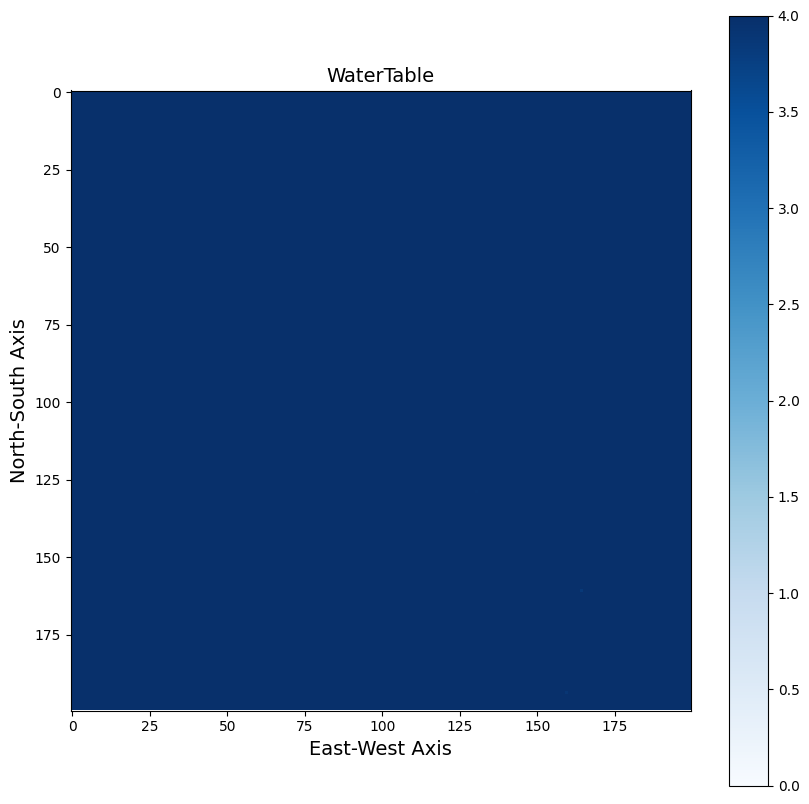

In [34]:
# plot the water level for just the crops region

def plot_water_table(timestep):
    crops_wtable = []
    
    for i in range(se_start_row, ny):
        row = []
        for j in range(se_start_col, nx):
            row.append(W[i][j][timestep])
        crops_wtable.append(row)
    
    #plot vegetation cover
    plt.figure(figsize=(10, 10))
    plt.imshow(crops_wtable, vmin=0, vmax=4)

    plt.xlabel('East-West Axis', fontsize=14)
    plt.ylabel('North-South Axis', fontsize=14)
    plt.title('WaterTable', fontsize=14);
    plt.set_cmap("Blues")
    plt.colorbar()
    
    plt.show()
        
plot_water_table(7*24)

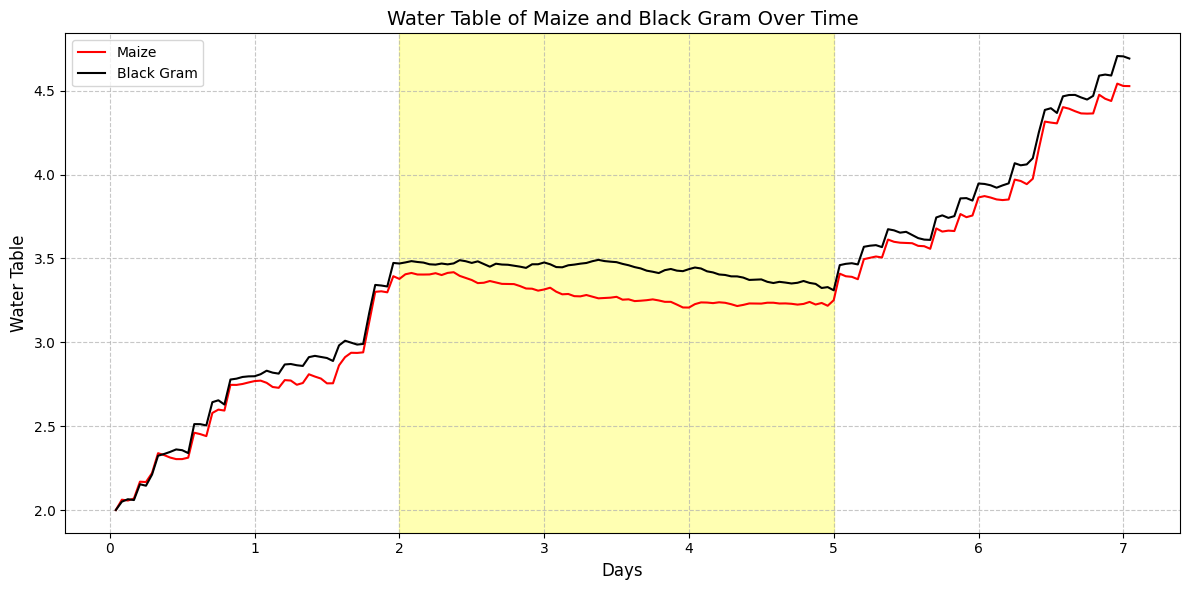

In [35]:
###### Show water table evolution at a points near middle of Maize and Black Gram fields

import matplotlib.pyplot as plt

days = [i/24 for i in range(1, ntimes+1)]

# Create the line graph
plt.figure(figsize=(12, 6))
plt.plot(days, W[825][225], label='Maize', color='red')
plt.plot(days, W[725][225], label='Black Gram', color='black')
#plt.plot(days, W[667][325], label='Reservoir', color='blue')
#plt.ylim(28, 32)

plt.xlabel('Days', fontsize=12)
plt.ylabel('Water Table', fontsize=12)
plt.title('Water Table of Maize and Black Gram Over Time', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight the drought period
drought_start = drought_start_day
drought_end = drought_start_day + drought_duration_days
plt.axvspan(drought_start, drought_end, color='yellow', alpha=0.3, label='Drought Period')

plt.tight_layout()
plt.show()